In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import re

In [2]:
sim_dirs = {
    '0bg_synapses_no_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-14-26-0bg_synapses_no_rhythm/allinh_rhythmic_depth_0.00_Np5000',
    '10000bg_synapses_no_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-14-14-10000bg_synapses_no_rhythm/allinh_rhythmic_depth_0.00_Np5000',
    '20000bg_synapses_no_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-14-37-20000bg_synapses_no_rhythm/allinh_rhythmic_depth_0.00_Np5000',
    '23930bg_synapses_with_no_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-10-23930bg_synapses_no_rhythm/allinh_rhythmic_depth_0.00_Np5000',

    '0bg_synapses_with_both_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-26-0bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000',
    '10000bg_synapses_with_both_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-16-07-10000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000',
    '20000bg_synapses_with_both_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-54-20000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000',
    '23930bg_synapses_with_both_rhythm': '/home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-37-23930bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000'
}

In [3]:
results = []

for label, sim_path in sim_dirs.items():
    csv_path = os.path.join(sim_path, "dSpike_table.csv")
    if not os.path.exists(csv_path):
        print(f"⚠️ Missing file: {csv_path}")
        continue
    
    df = pd.read_csv(csv_path)
    soma_rate = df.loc[df["Segment_Type"] == "dend", "Soma_Spike_Rate"]
    if soma_rate.empty:
        print(f"⚠️ No soma entry in {csv_path}")
        continue

    # Extract number of background synapses
    match = re.search(r"(\d+)bg", label)
    n_bg = int(match.group(1)) if match else None

    # Rhythm condition detection
    if "no_rhythm" in label:
        rhythm = "no_rhythm"
    elif "0.05rhythm" in label or "rhythm" in label:
        rhythm = "0.05rhythm"
    else:
        rhythm = "other"

    results.append((n_bg, rhythm, soma_rate.values[0]))

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["N_bg_synapses", "Rhythm", "Soma_Spike_Rate"])


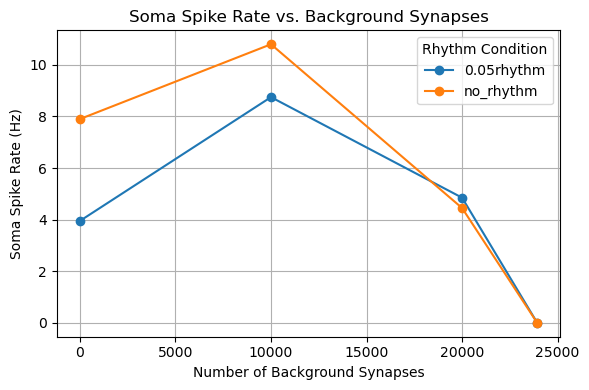

In [4]:
# Plot grouped by rhythm condition
plt.figure(figsize=(6, 4))

for rhythm, group in results_df.groupby("Rhythm"):
    group = group.sort_values("N_bg_synapses")
    plt.plot(group["N_bg_synapses"], group["Soma_Spike_Rate"],
             marker="o", linestyle="-", label=rhythm)

plt.xlabel("Number of Background Synapses")
plt.ylabel("Soma Spike Rate (Hz)")
plt.title("Soma Spike Rate vs. Background Synapses")
plt.grid(True)
plt.legend(title="Rhythm Condition")
plt.tight_layout()
plt.show()

In [5]:
import os
import re
import glob
import pandas as pd


def _find_synapses_csv(sim_path: str) -> str | None:
    """Return a path to synapses.csv (direct or via recursive search), else None."""
    direct = os.path.join(sim_path, "synapses.csv")
    if os.path.isfile(direct):
        return direct
    # Search recursively (first hit)
    hits = glob.glob(os.path.join(sim_path, "**", "synapses.csv"), recursive=True)
    return hits[0] if hits else None

def _parse_spike_train(cell) -> int:
    """
    Return spike count from a spike_train cell that may look like:
    [], [1,2,3], [1 2 3], "[11646 16860]", etc.
    """
    if pd.isna(cell):
        return 0
    s = str(cell).strip()
    if s in ("", "[]"):
        return 0
    # Extract all integers robustly
    ints = re.findall(r"-?\d+", s)
    return len(ints)

def _extract_n_bg_and_rhythm(label: str, path: str) -> tuple[int | None, str]:
    """Infer N_bg_synapses and Rhythm from the label/path."""
    # N_bg from label first, else from path
    m = re.search(r"(\d+)bg", label)
    if not m:
        m = re.search(r"(\d+)bg", path)
    n_bg = int(m.group(1)) if m else None

    # Rhythm: prefer explicit label tokens, otherwise infer from rhythmic depth in the path
    if "no_rhythm" in label or re.search(r"rhythmic_depth_0\.00", path):
        rhythm = "no_rhythm"
    elif "0.05rhythm" in label or re.search(r"rhythmic_depth_0\.05", path):
        rhythm = "0.05rhythm"
    else:
        # Fallback: anything with "rhythm" but not clearly 0.00/0.05
        if "rhythm" in label or "rhythm" in path:
            rhythm = "rhythm_other"
        else:
            rhythm = "no_rhythm"  # conservative default if nothing is stated
    return n_bg, rhythm

def compute_energetics(sim_dirs: dict) -> pd.DataFrame:
    """
    For each sim: load synapses.csv, sum spike counts across all rows,
    and return a tidy dataframe similar to the earlier 'first dataframe':
    columns = ['Label','Sim_Path','N_bg_synapses','Rhythm','N_Synapses','Total_Input_Spikes','Spikes_per_Synapse']
    """
    rows = []

    for label, sim_path in sim_dirs.items():
        csv_path = _find_synapses_csv(sim_path)
        if csv_path is None:
            print(f"⚠️ Missing file: {os.path.join(sim_path, 'synapses.csv')}")
            # Skip adding a broken row so the table stays clean
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"⚠️ Failed to read {csv_path}: {e}")
            continue

        if "spike_train" not in df.columns:
            print(f"⚠️ No 'spike_train' column in {csv_path}")
            continue

        # Count spikes per row
        spike_counts = df["spike_train"].apply(_parse_spike_train)
        total_spikes = int(spike_counts.sum())
        n_syn = int(len(df))

        n_bg, rhythm = _extract_n_bg_and_rhythm(label, sim_path)
        # spikes_per_syn = (total_spikes / n_syn) if n_syn > 0 else float("nan")

        rows.append({
            "Label": label,
            "Sim_Path": sim_path,
            "N_bg_synapses": n_bg,
            "Rhythm": rhythm,
            "N_Synapses": n_syn,
            "Total_Input_Spikes": total_spikes,
            # "Spikes_per_Synapse": spikes_per_syn,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["Rhythm", "N_bg_synapses"], kind="mergesort").reset_index(drop=True)
    return out

# --- Run and inspect ---
energetics_df = compute_energetics(sim_dirs)
print(energetics_df.to_string(index=False))

                            Label                                                                                                                          Sim_Path  N_bg_synapses     Rhythm  N_Synapses  Total_Input_Spikes
    0bg_synapses_with_both_rhythm     /home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-26-0bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000              0 0.05rhythm       23930             1427882
10000bg_synapses_with_both_rhythm /home/drfrbc/Neural-Modeling/simulations/2025-09-19-16-07-10000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000          10000 0.05rhythm       23930              861356
20000bg_synapses_with_both_rhythm /home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-54-20000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000          20000 0.05rhythm       23930              283998
23930bg_synapses_with_both_rhythm /home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-37-23930bg_synapses_wit

Saved: energetics_soma_summary.csv
                            Label                                                                                                                          Sim_Path  N_bg_synapses     Rhythm  N_Synapses  Total_Input_Spikes  Spikes_per_Synapse  Soma_Spike_Rate
    0bg_synapses_with_both_rhythm     /home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-26-0bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000              0 0.05rhythm       23930             1427882           59.669118             3.95
10000bg_synapses_with_both_rhythm /home/drfrbc/Neural-Modeling/simulations/2025-09-19-16-07-10000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000          10000 0.05rhythm       23930              861356           35.994818             8.75
20000bg_synapses_with_both_rhythm /home/drfrbc/Neural-Modeling/simulations/2025-09-19-15-54-20000bg_synapses_with_both_rhythm0.05/allinh_rhythmic_depth_0.05_Np5000          20000 0.05rhyth

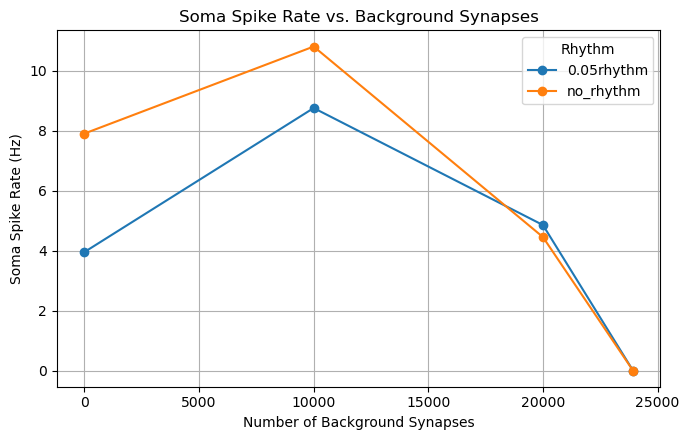

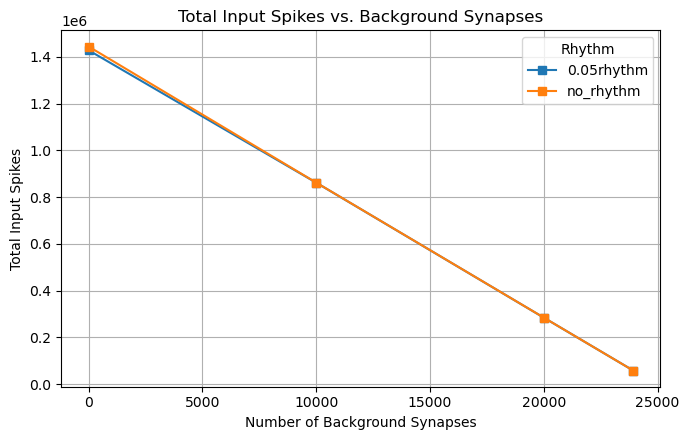

In [6]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Define your simulations
# =========================

# =========================
# 2) Helpers
# =========================
def _find_file(sim_path: str, filename: str) -> str | None:
    """Return direct path if present, else first recursive hit for filename, else None."""
    direct = os.path.join(sim_path, filename)
    if os.path.isfile(direct):
        return direct
    hits = glob.glob(os.path.join(sim_path, "**", filename), recursive=True)
    return hits[0] if hits else None

def _parse_spike_train_count(cell) -> int:
    """Return count of spikes from a spike_train cell like [], [1,2], [1 2], or '[11646 16860]'."""
    if pd.isna(cell):
        return 0
    s = str(cell).strip()
    if s == "" or s == "[]":
        return 0
    ints = re.findall(r"-?\d+", s)
    return len(ints)

def _extract_n_bg_and_rhythm(label: str, path: str) -> tuple[int | None, str]:
    """Infer N_bg_synapses and Rhythm from label/path."""
    m = re.search(r"(\d+)bg", label) or re.search(r"(\d+)bg", path)
    n_bg = int(m.group(1)) if m else None

    if "no_rhythm" in label or re.search(r"rhythmic_depth_0\.00", path):
        rhythm = "no_rhythm"
    elif "0.05rhythm" in label or re.search(r"rhythmic_depth_0\.05", path):
        rhythm = "0.05rhythm"
    else:
        rhythm = "rhythm_other" if ("rhythm" in label or "rhythm" in path) else "no_rhythm"
    return n_bg, rhythm

# =========================
# 3) Build energetics df
# =========================
def compute_energetics_df(sim_dirs: dict) -> pd.DataFrame:
    rows = []
    for label, sim_path in sim_dirs.items():
        syn_csv = _find_file(sim_path, "synapses.csv")
        if syn_csv is None:
            print(f"⚠️ Missing file: {os.path.join(sim_path, 'synapses.csv')}")
            continue

        try:
            df = pd.read_csv(syn_csv)
        except Exception as e:
            print(f"⚠️ Failed to read {syn_csv}: {e}")
            continue

        if "spike_train" not in df.columns:
            print(f"⚠️ No 'spike_train' column in {syn_csv}")
            continue

        spike_counts = df["spike_train"].apply(_parse_spike_train_count)
        total_spikes = int(spike_counts.sum())
        n_syn = int(len(df))

        n_bg, rhythm = _extract_n_bg_and_rhythm(label, sim_path)
        spikes_per_syn = (total_spikes / n_syn) if n_syn > 0 else float("nan")

        rows.append({
            "Label": label,
            "Sim_Path": sim_path,
            "N_bg_synapses": n_bg,
            "Rhythm": rhythm,
            "N_Synapses": n_syn,
            "Total_Input_Spikes": total_spikes,
            "Spikes_per_Synapse": spikes_per_syn,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["Rhythm", "N_bg_synapses"], kind="mergesort").reset_index(drop=True)
    return out

# =========================
# 4) Load soma spike rate per sim
# =========================
def load_soma_rate(label: str, sim_path: str) -> dict | None:
    """Return {'Label','N_bg_synapses','Rhythm','Soma_Spike_Rate'} for a simulation, or None."""
    dspike_csv = _find_file(sim_path, "dSpike_table.csv")
    if dspike_csv is None:
        print(f"⚠️ Missing file: {os.path.join(sim_path, 'dSpike_table.csv')}")
        return None

    try:
        df = pd.read_csv(dspike_csv)
    except Exception as e:
        print(f"⚠️ Failed to read {dspike_csv}: {e}")
        return None

    # Prefer explicit soma row; if not present, fall back to the first row's value
    soma_row = None
    if "Segment_Type" in df.columns:
        soma_rows = df[df["Segment_Type"].astype(str).str.lower() == "soma"]
        if not soma_rows.empty:
            soma_row = soma_rows.iloc[0]

    try:
        if soma_row is not None:
            soma_rate = float(soma_row["Soma_Spike_Rate"])
        else:
            soma_rate = float(df["Soma_Spike_Rate"].iloc[0])
    except Exception:
        print(f"⚠️ Could not read Soma_Spike_Rate in {dspike_csv}")
        return None

    n_bg, rhythm = _extract_n_bg_and_rhythm(label, sim_path)
    return {
        "Label": label,
        "N_bg_synapses": n_bg,
        "Rhythm": rhythm,
        "Soma_Spike_Rate": soma_rate,
    }

def build_soma_df(sim_dirs: dict) -> pd.DataFrame:
    rows = []
    for label, sim_path in sim_dirs.items():
        rec = load_soma_rate(label, sim_path)
        if rec is not None:
            rows.append(rec)
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Rhythm", "N_bg_synapses"], kind="mergesort").reset_index(drop=True)
    return df

# =========================
# 5) Merge + Save + Figure
# =========================
energetics_df = compute_energetics_df(sim_dirs)
soma_df = build_soma_df(sim_dirs)

combined = pd.merge(
    energetics_df,
    soma_df[["Label", "N_bg_synapses", "Rhythm", "Soma_Spike_Rate"]],
    on=["Label", "N_bg_synapses", "Rhythm"],
    how="outer"
).sort_values(["Rhythm", "N_bg_synapses"], kind="mergesort").reset_index(drop=True)

# Save table for reference
out_csv = "energetics_soma_summary.csv"
combined.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print(combined.to_string(index=False))

# --- Figure: Soma Spike Rate vs N_bg_synapses (two lines by Rhythm) ---
plt.figure(figsize=(7, 4.5))

for rhythm, grp in combined.groupby("Rhythm"):
    grp = grp.dropna(subset=["N_bg_synapses", "Soma_Spike_Rate"]).sort_values("N_bg_synapses")
    if grp.empty:
        continue
    plt.plot(grp["N_bg_synapses"], grp["Soma_Spike_Rate"], marker="o", linestyle="-", label=rhythm)

plt.xlabel("Number of Background Synapses")
plt.ylabel("Soma Spike Rate (Hz)")
plt.title("Soma Spike Rate vs. Background Synapses")
plt.grid(True)
plt.legend(title="Rhythm")
plt.tight_layout()
fig_path = "soma_rate_vs_bg_synapses.png"
# plt.savefig(fig_path, dpi=300)
# plt.close()
# print(f"Saved figure: {fig_path}")

# (Optional) Second figure: Total Input Spikes vs N_bg_synapses
# Uncomment if you want this as well.
plt.figure(figsize=(7, 4.5))
for rhythm, grp in combined.groupby("Rhythm"):
    grp = grp.dropna(subset=["N_bg_synapses", "Total_Input_Spikes"]).sort_values("N_bg_synapses")
    if grp.empty:
        continue
    plt.plot(grp["N_bg_synapses"], grp["Total_Input_Spikes"], marker="s", linestyle="-", label=rhythm)
plt.xlabel("Number of Background Synapses")
plt.ylabel("Total Input Spikes")
plt.title("Total Input Spikes vs. Background Synapses")
plt.grid(True)
plt.legend(title="Rhythm")
plt.tight_layout()
fig_path2 = "total_input_spikes_vs_bg_synapses.png"
# plt.savefig(fig_path2, dpi=300)
# plt.close()
# print(f"Saved figure: {fig_path2}")
